In [1]:
import pandas as pd

# File path (adjust if uploaded differently in Colab)
file_path = "/content/KDDTrain+_20Percent.txt"

# Column names (from NSL-KDD documentation)
columns = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in","num_compromised",
    "root_shell","su_attempted","num_root","num_file_creations","num_shells",
    "num_access_files","num_outbound_cmds","is_host_login","is_guest_login","count",
    "srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count",
    "dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
    "class","difficulty"
]

df = pd.read_csv(file_path, names=columns)

print(" Dataset Loaded")
print("Shape:", df.shape)
df.head()


 Dataset Loaded
Shape: (25192, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


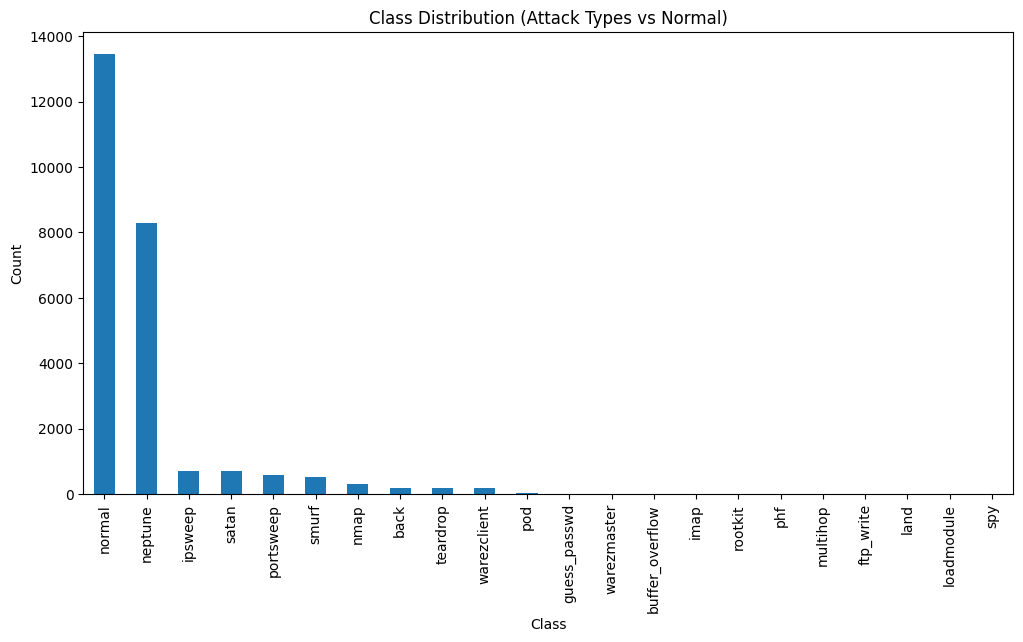

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
df['class'].value_counts().plot(kind='bar')
plt.title("Class Distribution (Attack Types vs Normal)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


**Protocol distribution**

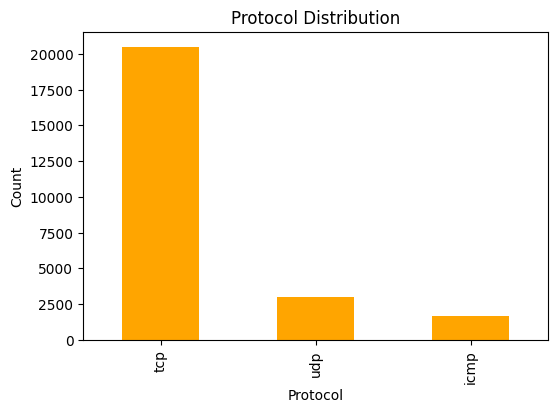

In [3]:
plt.figure(figsize=(6,4))
df['protocol_type'].value_counts().plot(kind='bar', color='orange')
plt.title("Protocol Distribution")
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()


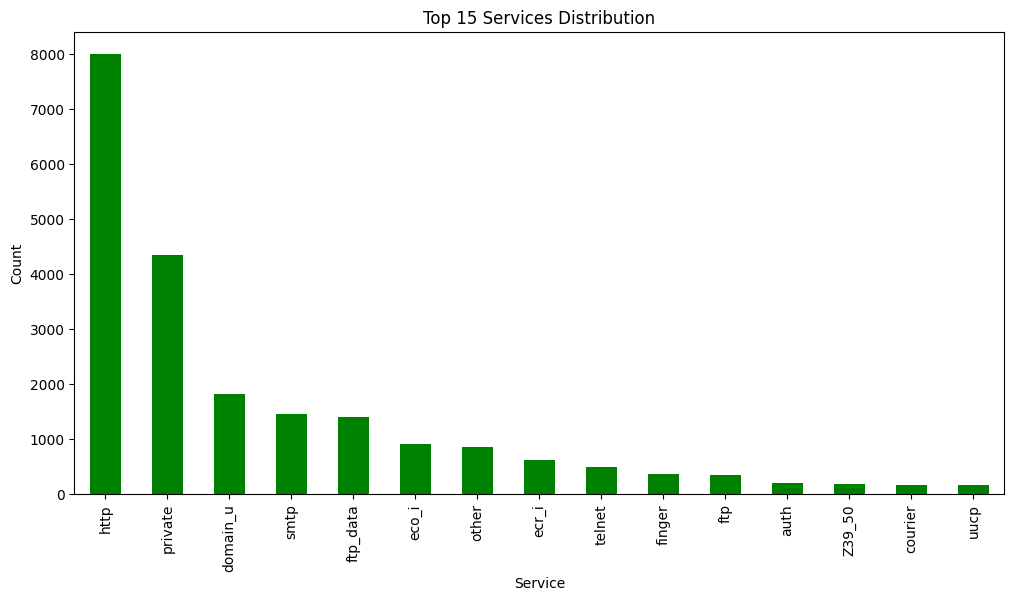

In [4]:
plt.figure(figsize=(12,6))
df['service'].value_counts().nlargest(15).plot(kind='bar', color='green')
plt.title("Top 15 Services Distribution")
plt.xlabel("Service")
plt.ylabel("Count")
plt.show()


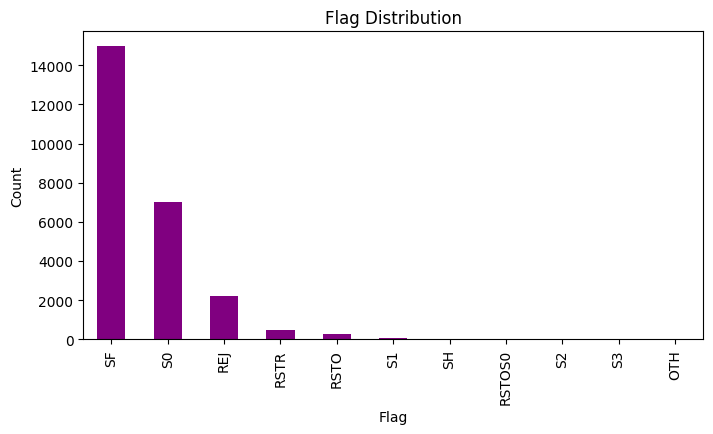

In [5]:
plt.figure(figsize=(8,4))
df['flag'].value_counts().plot(kind='bar', color='purple')
plt.title("Flag Distribution")
plt.xlabel("Flag")
plt.ylabel("Count")
plt.show()


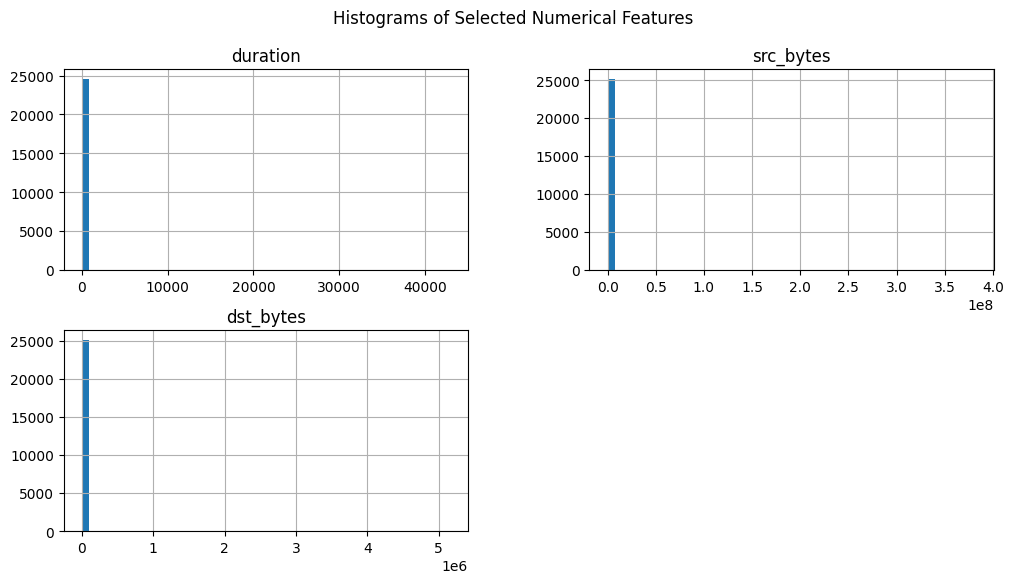

In [6]:
num_features = ["duration", "src_bytes", "dst_bytes"]

df[num_features].hist(figsize=(12,6), bins=50)
plt.suptitle("Histograms of Selected Numerical Features")
plt.show()


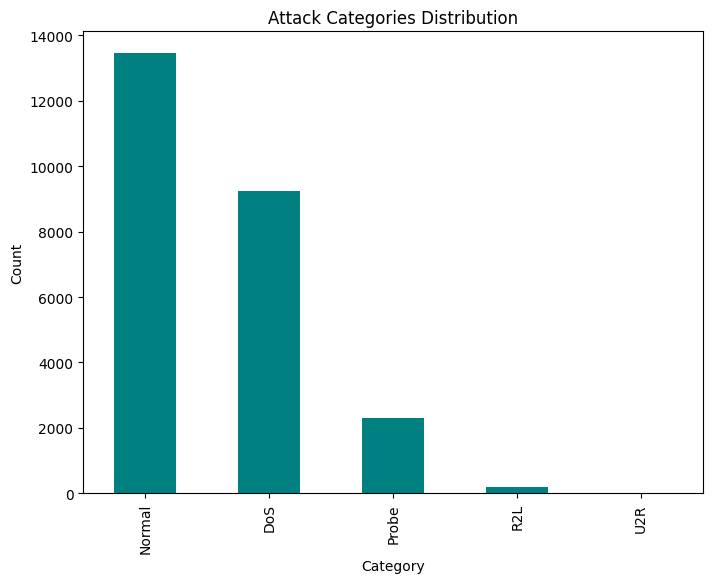

,class,attack_category
0,normal,Normal
1,normal,Normal
2,neptune,DoS
3,normal,Normal
4,normal,Normal
5,neptune,DoS
6,neptune,DoS
7,neptune,DoS
8,neptune,DoS
9,neptune,DoS


In [7]:
# Define attack category mapping
attack_categories = {
    "normal": "Normal",

    # DoS Attacks
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "apache2": "DoS", "udpstorm": "DoS",
    "processtable": "DoS", "worm": "DoS",

    # Probe Attacks
    "satan": "Probe", "ipsweep": "Probe", "nmap": "Probe", "portsweep": "Probe",
    "mscan": "Probe", "saint": "Probe",

    # R2L Attacks
    "ftp_write": "R2L", "guess_passwd": "R2L", "imap": "R2L", "multihop": "R2L",
    "phf": "R2L", "spy": "R2L", "warezclient": "R2L", "warezmaster": "R2L",
    "sendmail": "R2L", "named": "R2L", "snmpgetattack": "R2L", "snmpguess": "R2L",
    "xlock": "R2L", "xsnoop": "R2L", "worm": "R2L",

    # U2R Attacks
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R", "rootkit": "U2R",
    "httptunnel": "U2R", "ps": "U2R", "sqlattack": "U2R", "xterm": "U2R"
}

# Map each record to its category
df["attack_category"] = df["class"].map(attack_categories)

# ----------------------------
# Plot Attack Categories
# ----------------------------
plt.figure(figsize=(8,6))
df["attack_category"].value_counts().plot(kind="bar", color="teal")
plt.title("Attack Categories Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

# Preview dataset with new column
df[["class","attack_category"]].head(10)


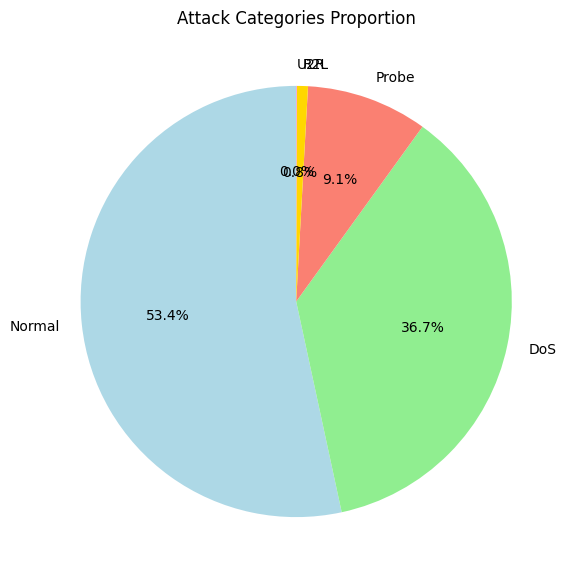

In [8]:
# ----------------------------
# Pie Chart of Attack Categories
# ----------------------------
plt.figure(figsize=(7,7))
df["attack_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightblue","lightgreen","salmon","gold","violet"]
)

plt.title("Attack Categories Proportion")
plt.ylabel("")  # hide y-label
plt.show()


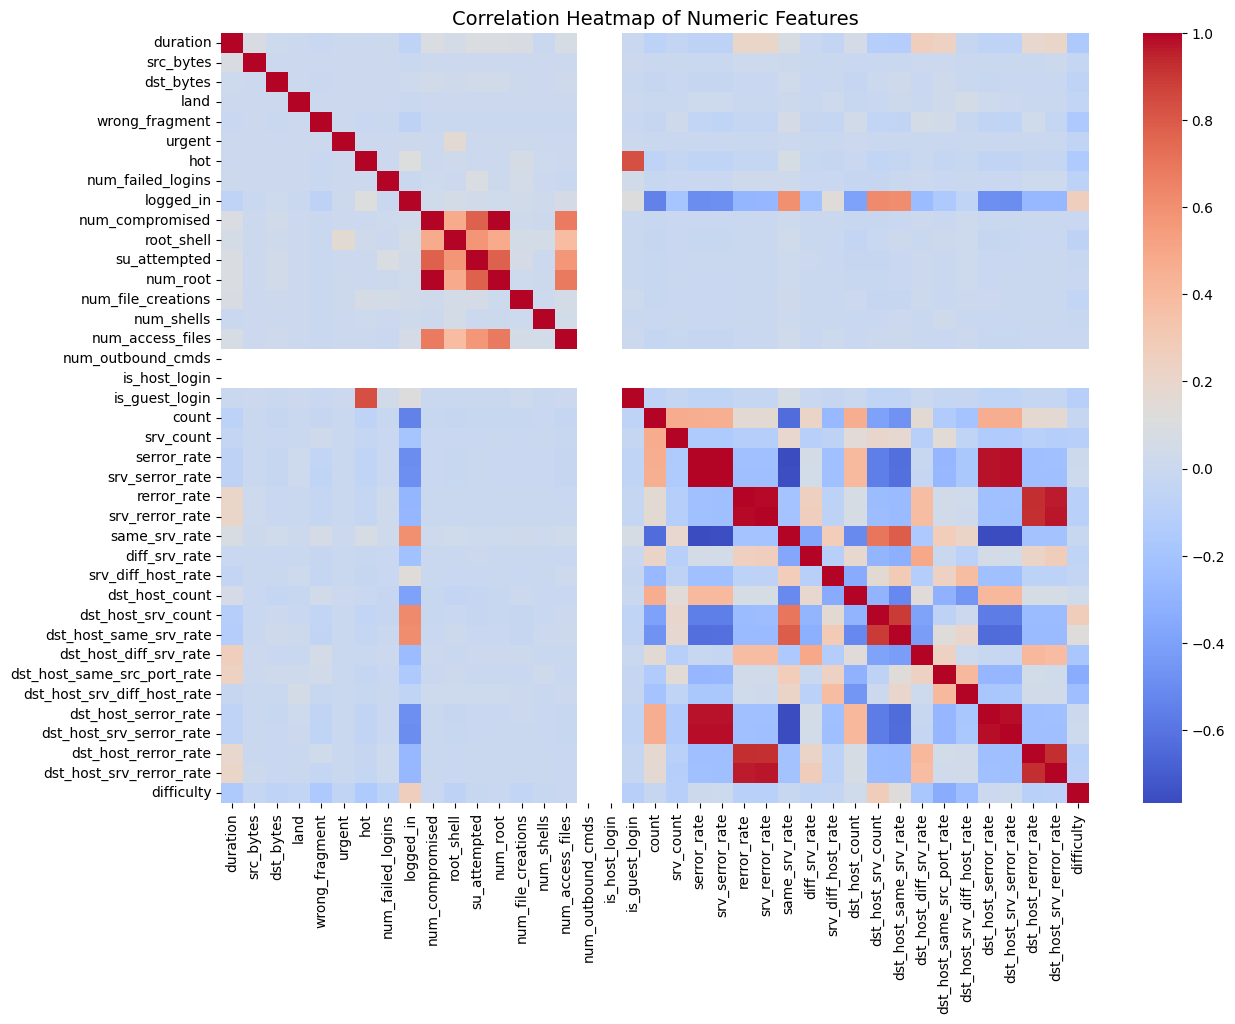

In [9]:
import seaborn as sns

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64','float64'])

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()


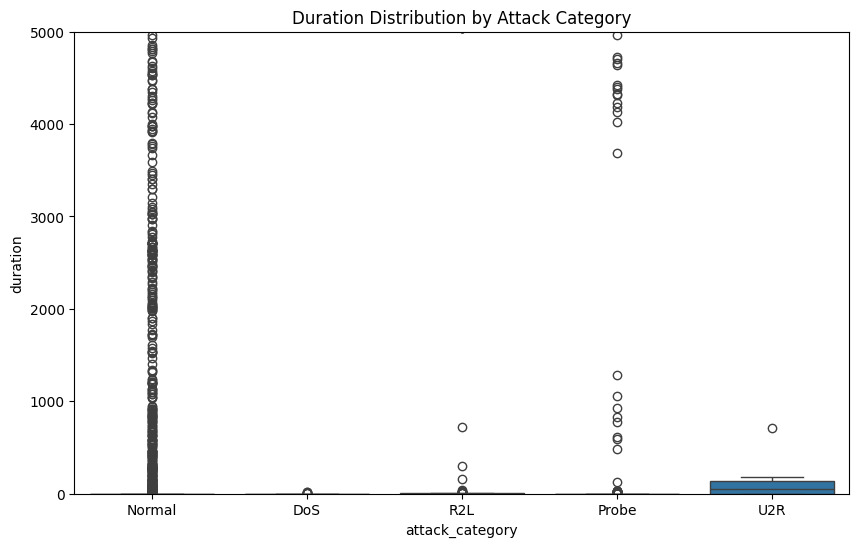

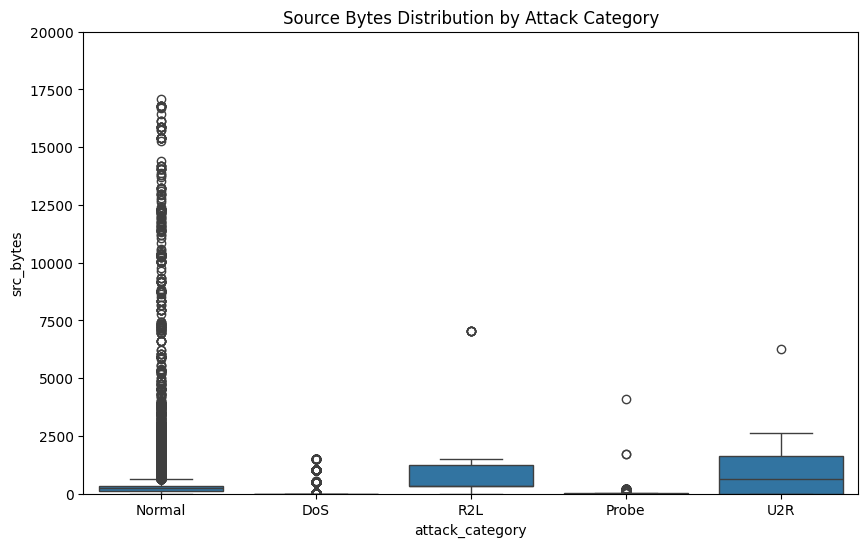

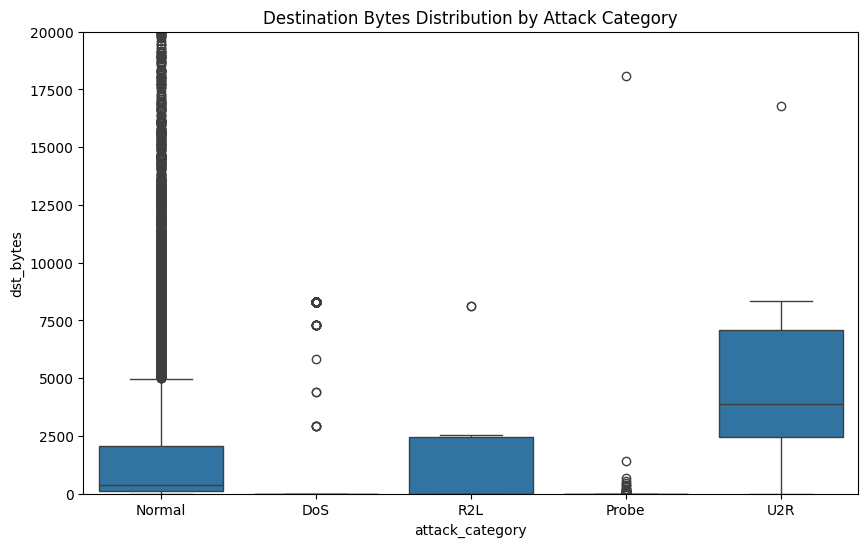

In [10]:
import seaborn as sns

# 1. Duration vs Attack Category
plt.figure(figsize=(10,6))
sns.boxplot(x="attack_category", y="duration", data=df)
plt.ylim(0, 5000)  # limit to see patterns clearly
plt.title("Duration Distribution by Attack Category")
plt.show()

# 2. Source Bytes vs Attack Category
plt.figure(figsize=(10,6))
sns.boxplot(x="attack_category", y="src_bytes", data=df)
plt.ylim(0, 20000)
plt.title("Source Bytes Distribution by Attack Category")
plt.show()

# 3. Destination Bytes vs Attack Category
plt.figure(figsize=(10,6))
sns.boxplot(x="attack_category", y="dst_bytes", data=df)
plt.ylim(0, 20000)
plt.title("Destination Bytes Distribution by Attack Category")
plt.show()


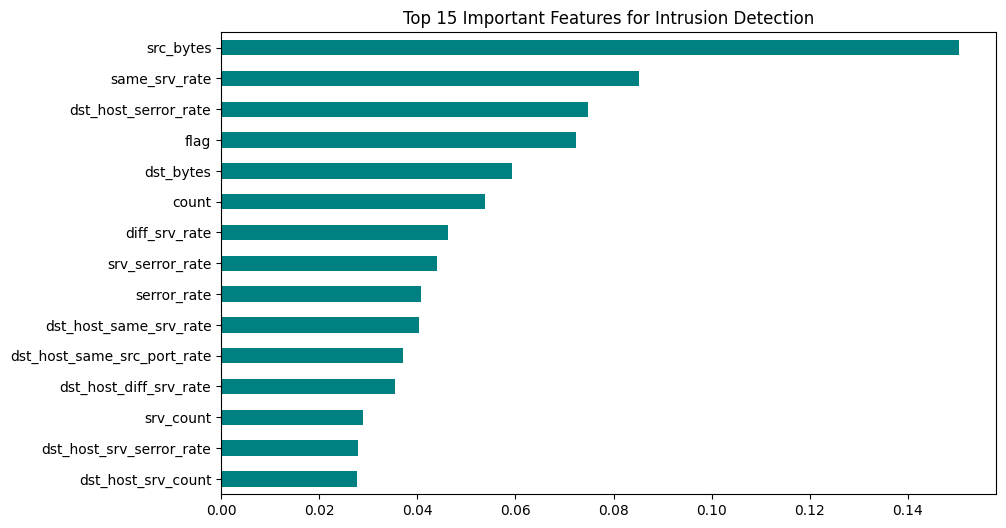

,0
src_bytes,0.150443
same_srv_rate,0.085118
dst_host_serror_rate,0.074760
flag,0.072419
dst_bytes,0.059241
count,0.053859
diff_srv_rate,0.046344
srv_serror_rate,0.043953
serror_rate,0.040817
dst_host_same_srv_rate,0.040321


In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

# ----------------------------
# Encode categorical features
# ----------------------------
df_encoded = df.copy()
cat_cols = ["protocol_type", "service", "flag", "class", "attack_category"]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le  # store encoder for later use

# ----------------------------
# Train RandomForest
# ----------------------------
X = df_encoded.drop(columns=["class","attack_category","difficulty"])
y = df_encoded["attack_category"]

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# ----------------------------
# Feature Importance
# ----------------------------
importances = model.feature_importances_
feat_importances = pd.Series(importances, index=X.columns)

# Top 15 features
top_features = feat_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
top_features.plot(kind="barh", color="teal")
plt.title("Top 15 Important Features for Intrusion Detection")
plt.gca().invert_yaxis()
plt.show()

top_features


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1847
           1       0.99      1.00      1.00      2690
           2       1.00      0.98      0.99       458
           3       1.00      0.90      0.95        42
           4       0.00      0.00      0.00         2

    accuracy                           1.00      5039
   macro avg       0.80      0.78      0.79      5039
weighted avg       1.00      1.00      1.00      5039



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


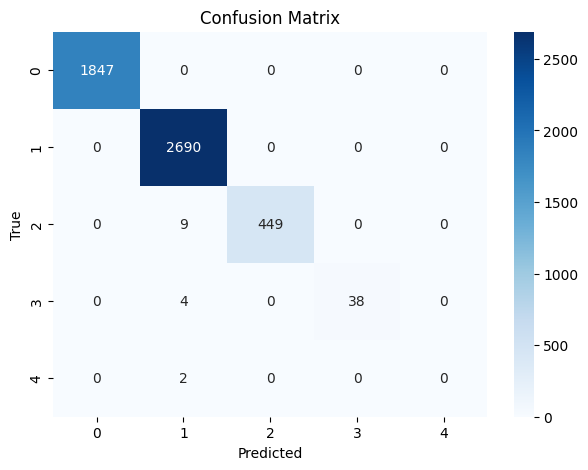

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ----------------------------
# Features (X) and Target (y)
# ----------------------------
X = df_encoded.drop(columns=["class","attack_category","difficulty"])
y = df_encoded["attack_category"]

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# Train RandomForest Classifier
# ----------------------------
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# ----------------------------
# Evaluation Metrics
# ----------------------------
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
